--- Training Data Counts ---
glioma: 1400 images
meningioma: 1400 images
pituitary: 1400 images
notumor: 1400 images


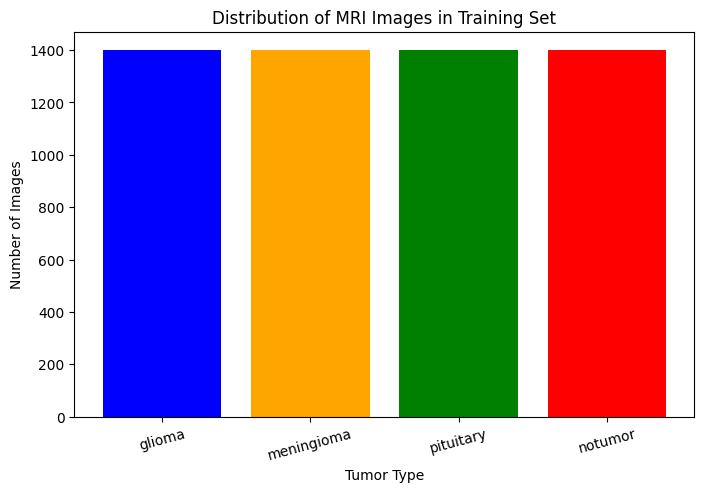

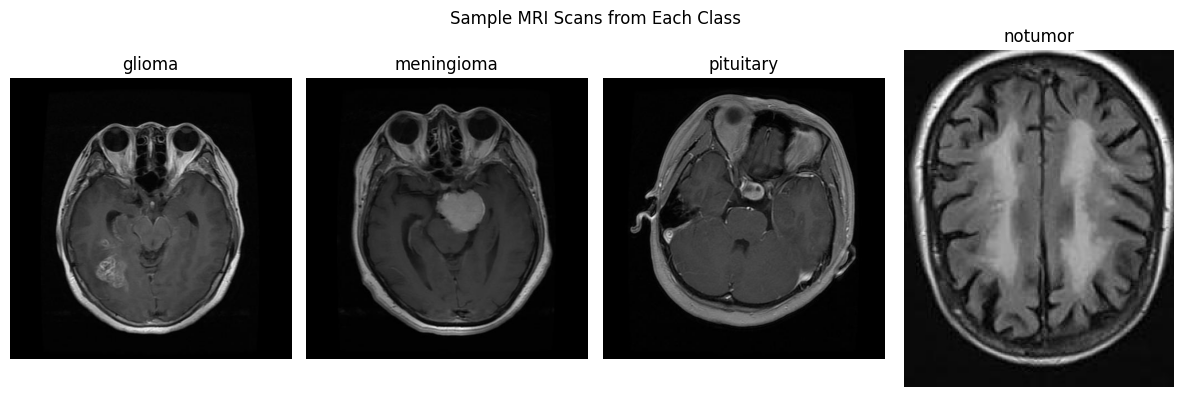


--- Starting Preprocessing ---
Processing glioma...
Processing meningioma...
Processing pituitary...
Processing notumor...

--- Preprocessing Complete ---
Final Training Data Shape: (2000, 224, 224, 3)


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

trainDir = 'Training'
categories = ['glioma', 'meningioma', 'pituitary', 'notumor']

trainCounts = []
print("Training Data Counts")

for category in categories:
    folderPath = os.path.join(trainDir, category)
    numImages = len(os.listdir(folderPath))
    trainCounts.append(numImages)
    print(f"{category}: {numImages} images")

# Plotting the Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(categories, trainCounts, color=['blue', 'orange', 'green', 'red'])
plt.title('Distribution of MRI Images in Training Set')
plt.xlabel('Tumor Type')
plt.ylabel('Number of Images')
plt.xticks(rotation=15)
plt.show() 


plt.figure(figsize=(12, 4))

for i, category in enumerate(categories):
    folderPath = os.path.join(trainDir, category)
    firstImageName = os.listdir(folderPath)[0]
    imgPath = os.path.join(folderPath, firstImageName)
    
    img = Image.open(imgPath).convert('RGB')
    
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')

plt.suptitle("Sample MRI Scans from Each Class")
plt.tight_layout()
plt.show() 

imgSize = 224 

def createDataset(directory):
    datasetImages = []
    datasetLabels = []
    
    for classIndex, category in enumerate(categories):
        folderPath = os.path.join(directory, category)
        print(f"Processing {category}...")
        
        for imgName in os.listdir(folderPath)[:500]: 
            imgPath = os.path.join(folderPath, imgName)
            
            try:
                img = Image.open(imgPath).convert('RGB').resize((imgSize, imgSize))
                
                normalizedArray = np.array(img) / 255.0
                
                datasetImages.append(normalizedArray)
                datasetLabels.append(classIndex)
            except:
                pass
                
    return np.array(datasetImages), np.array(datasetLabels)

print("\n Starting Preprocessing")
xTrain, yTrain = createDataset(trainDir)

print("\n Preprocessing Complete")
print(f"Final Training Data Shape: {xTrain.shape}")